In [ ]:
#Building a recommendation system using item-based collaborative filtering(Cosine Similarity)
#GONDU SUDARSANA RAO currently codtech intern

In [2]:
import pandas as pd

In [3]:
#Loading dataset, dataset- MovieLens 100K
ratings_cols= ['user_id', 'item_id', 'rating', 'timestamp']
ratings= pd.read_csv('u.data', sep='\t', names=ratings_cols)
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
#This contains movie titles 
item_columns= ['item_id', 'title'] + [str(i) for i in range(22)]
movies= pd.read_csv('u.item', sep='|', encoding='latin-1', names=item_columns, usecols=[0, 1])
movies.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [5]:
#Preprocessing
ratings.drop('timestamp', axis=1, inplace=True)# Removing unrequired column
# Merge movie names with ratings
ratings= ratings.merge(movies, on='item_id')#Merging Movie title with Ratings

ratings.head()#Displaying firsrt 5 Rows

,user_id,item_id,rating,title
0,196,242,3,Kolya (1996)
1,186,302,3,L.A. Confidential (1997)
2,22,377,1,Heavyweights (1994)
3,244,51,2,Legends of the Fall (1994)
4,166,346,1,Jackie Brown (1997)


Unique Users: 943
Unique Movies: 1664


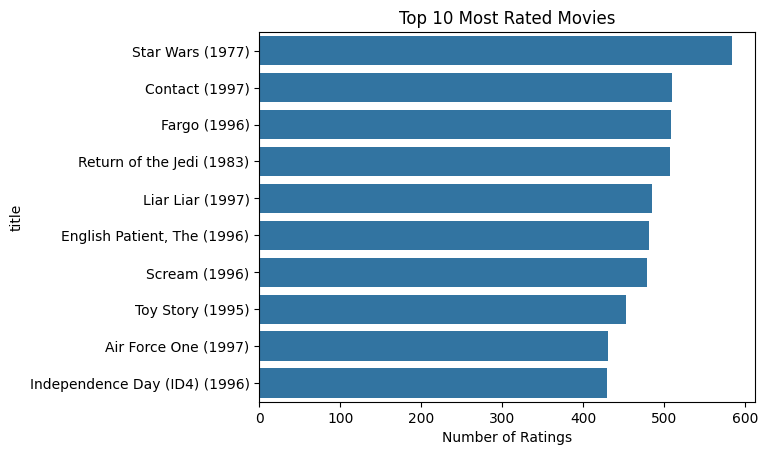

In [8]:
# Exploratory data analysis- For more detailed analysis of data- to extract info from data
import matplotlib.pyplot as plt#Importing visualization modules
import seaborn as sns
print("Unique Users:", ratings['user_id'].nunique())
print("Unique Movies:", ratings['title'].nunique())

top_movies = ratings['title'].value_counts().head(10)
sns.barplot(x=top_movies.values, y=top_movies.index
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.show()

In [20]:
# Feature Extraction
# We created the matrix to numerically represent user preferences and allow computation of similarity between items (or users) to make smart recommendations.
matrix= ratings.pivot_table(index='user_id',columns='title',values='rating').fillna(0)#User-item matrix
matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0


In [21]:
# Model architecture
from sklearn.metrics.pairwise import cosine_similarity
item_similarity= cosine_similarity(matrix.T)#Using predefined function from scikit-learn

# Store in DataFrame
df= pd.DataFrame(item_similarity, index=matrix.columns, columns=matrix.columns)

df.head()
# Cosine similarity - so it simply calculates angle between two vectors(Vector1-[Movie 1 info],Vector2-[Movie 2 info]) if angle is small then they are similar.
# normal dot product calculation

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
title,,,,,,,,,,,,,,,,,,,,,
'Til There Was You (1997),1.000000,0.000000,0.024561,0.099561,0.185236,0.159265,0.000000,0.052203,0.000000,0.033326,...,0.000000,0.000000,0.000000,0.027774,0.118840,0.142315,0.029070,0.000000,0.110208,0.000000
1-900 (1994),0.000000,1.000000,0.014139,0.009294,0.007354,0.004702,0.010055,0.067038,0.000000,0.000000,...,0.152499,0.015484,0.000000,0.069284,0.018243,0.023408,0.006694,0.079640,0.042295,0.000000
101 Dalmatians (1996),0.024561,0.014139,1.000000,0.167006,0.061105,0.143878,0.203781,0.225803,0.027642,0.092337,...,0.000000,0.021965,0.030905,0.274877,0.204267,0.101199,0.056976,0.172155,0.045714,0.000000
12 Angry Men (1957),0.099561,0.009294,0.167006,1.000000,0.056822,0.167235,0.304078,0.422506,0.072682,0.394854,...,0.060946,0.016502,0.000000,0.403270,0.259436,0.145519,0.105226,0.038901,0.060101,0.081261
187 (1997),0.185236,0.007354,0.061105,0.056822,1.000000,0.132327,0.042928,0.065060,0.043133,0.027300,...,0.000000,0.141997,0.000000,0.068257,0.067786,0.091293,0.099490,0.025184,0.142667,0.096449


In [18]:
def get_similar_movies(movie_name, top_n=5):#Function for recommending top 5 related moviees
    if movie_name not in df.columns:
        return f"Movie '{movie_name}' not found."
    scores=df[movie_name].sort_values(ascending=False)
    return scores.iloc[1:top_n+1]

In [19]:
get_similar_movies("Mission: Impossible (1996)")#Getting movies related to this movie

title
Independence Day (ID4) (1996)    0.781254
Rock, The (1996)                 0.720355
Twister (1996)                   0.681107
Eraser (1996)                    0.679930
Broken Arrow (1996)              0.670803
Name: Mission: Impossible (1996), dtype: float64

In [22]:
#Evaluation metrics
user_id = 1
watched_movies = ratings[ratings['user_id'] == user_id]['title'].values
recommended = get_similar_movies("Star Wars (1977)", 5).index

# Check how many recommended movies the user has rated
set(recommended).intersection(set(watched_movies))

{'Empire Strikes Back, The (1980)',
 'Godfather, The (1972)',
 'Raiders of the Lost Ark (1981)',
 'Return of the Jedi (1983)',
 'Toy Story (1995)'}

In [ ]:
#AMIT RAMCHANDRA MALI